<a href="https://colab.research.google.com/github/hafnailmy-bip/pertemuan1/blob/main/PCD_Tugas_Citra_Digital.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving Foto Tugas Citra Digital 2.jpeg to Foto Tugas Citra Digital 2.jpeg
Jumlah objek terdeteksi: 7


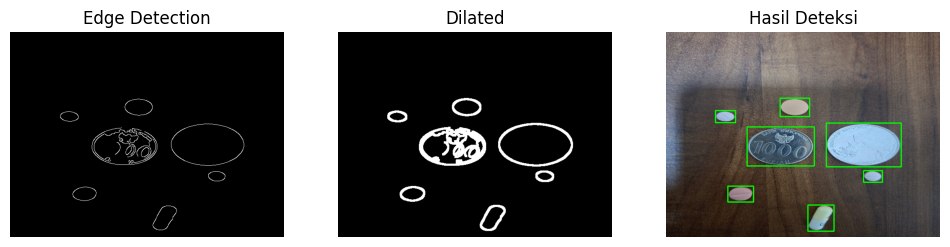

In [31]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# Upload gambar
uploaded = files.upload()
filename = list(uploaded.keys())[0]

# Baca gambar
image = cv2.imread(filename)
image = cv2.resize(image,(640,480))
output = image.copy()

# ===================== PREPROCESSING =====================
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
blur = cv2.GaussianBlur(gray,(7,7),0)

# Deteksi tepi
edges = cv2.Canny(blur,50,150)

# Dilasi biar objek utuh
kernel = np.ones((3,3),np.uint8)
dilated = cv2.dilate(edges,kernel,iterations=2)

# ===================== DETEKSI OBJEK =====================
contours,_ = cv2.findContours(dilated,cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_SIMPLE)

count = 0

for cnt in contours:
    area = cv2.contourArea(cnt)

    if area > 300:  # filter noise kecil
        count += 1
        x,y,w,h = cv2.boundingRect(cnt)
        cv2.rectangle(output,(x,y),(x+w,y+h),(0,255,0),2)

# ===================== OUTPUT =====================
print("Jumlah objek terdeteksi:",count)

plt.figure(figsize=(12,5))

plt.subplot(1,3,1)
plt.title("Edge Detection")
plt.imshow(edges,cmap='gray')
plt.axis('off')

plt.subplot(1,3,2)
plt.title("Dilated")
plt.imshow(dilated,cmap='gray')
plt.axis('off')

plt.subplot(1,3,3)
plt.title("Hasil Deteksi")
plt.imshow(cv2.cvtColor(output,cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.show()